☕ Ethiopia Coffee Market Analytics Dashboard

My project is an interactive and dynamic data analytics dashboard developed using Python, Streamlit, Pandas, NumPy, and Plotly. The main purpose of the project is to analyze Ethiopian coffee market trading data and transform raw data into meaningful visual insights.

The dashboard includes interactive filters, KPI cards, price and volume trend analysis, warehouse and coffee symbol analysis, High vs. Low price comparison, seasonality analysis, Top Gainers, automated market insights, price forecasting, cross-tabulation analysis, and filtered data download.

I also developed a Dynamic Analytics section where users can upload their own CSV or Excel datasets for basic data profiling, cleaning, visualization, and analysis.

The overall goal of my project is to help users understand market performance and support data-driven decision-making through interactive data visualization and analytics.

In [ ]:

# CORE DATA MANIPULATION & IMPORT LIBRARIES
import pandas as pd          # Data manipulation, cleaning, and analysis using DataFrames
import numpy as np           # Numerical computing and handling missing values (NaN)
import glob                  # Finds files matching a specific pattern (e.g., "Coffee-*.xlsx")
from datetime import datetime    # Creates, formats, and manipulates date and time objects
# DATA VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px       # Creates interactive and visually appealing charts
# NOTEBOOK CONFIGURATION
import warnings
warnings.filterwarnings('ignore')    # Suppresses unnecessary warning messages for cleaner output
# Displays Matplotlib plots directly inside the Jupyter Notebook
%matplotlib inline

i have different dataset with the same name so it must be merg to gether

In [160]:
# 1. Find all Excel files whose names start with "Coffee-"
excel_files = sorted(glob.glob("Coffee-*.xlsx"))

# 2. Read each Excel file and store the data in a list of DataFrames
df_list = [pd.read_excel(file) for file in excel_files]

# 3. Combine all DataFrames into a single DataFrame
df = pd.concat(df_list, ignore_index=True)

# 4. Save the combined DataFrame as a CSV file
# index=False prevents pandas from writing row index numbers into the CSV
df.to_csv("all_combined_coffee_data.csv", index=False)



**Data overview**
An overview is a brief general explanation or summary of a topic.
It gives the main idea without detailed information.

In [161]:
# 5. Display the first 5 rows of the combined dataset
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Trade Date,Symbol,Warehouse,Production Year,Opening Price,Closing Price,High,Low,Change,Persetntage Change,Volume (Ton)
2,2012-01-02 00:00:00,WYKQ2,BG,2004,"1,175.00",0.00,"1,175.00","1,175.00",0,0.0,28.29
3,2012-01-03 00:00:00,WYKQ2,BG,2004,"1,175.00",0.00,"1,175.00","1,175.00",0,0.0,10.8
4,2012-01-04 00:00:00,WYKQ2,BG,2004,"1,180.00",0.00,"1,180.00","1,180.00",0,0.0,6.61


In [162]:
# 1. Set the second row as the column headers
df.columns = df.iloc[1]

# 2. Remove the first two rows from the DataFrame
df = df.iloc[2:]

# 3. Reset the DataFrame index
df.reset_index(drop=True, inplace=True)

# 4. Display the first five rows of the cleaned DataFrame
df.head(5)

1,Trade Date,Symbol,Warehouse,Production Year,Opening Price,Closing Price,High,Low,Change,Persetntage Change,Volume (Ton)
0,2012-01-02 00:00:00,WYKQ2,BG,2004,"1,175.00",0.00,"1,175.00","1,175.00",0,0.0,28.29
1,2012-01-03 00:00:00,WYKQ2,BG,2004,"1,175.00",0.00,"1,175.00","1,175.00",0,0.0,10.8
2,2012-01-04 00:00:00,WYKQ2,BG,2004,"1,180.00",0.00,"1,180.00","1,180.00",0,0.0,6.61
3,2012-01-06 00:00:00,WYKQ2,BG,2004,"1,175.00",0.00,"1,175.00","1,175.00",0,0.0,8.99
4,2012-01-12 00:00:00,WYKQ2,BG,2004,"1,293.00",0.00,"1,293.00","1,280.00",0,0.0,18


In [163]:
df.columns ## show all columns

Index(['Trade Date', 'Symbol', 'Warehouse', 'Production Year', 'Opening Price',
       'Closing Price', 'High', 'Low', 'Change', 'Persetntage Change',
       'Volume (Ton)'],
      dtype='object', name=1)

**some descripition about the rows of the data set**
 Column Name           |Description                                                    
|**Trade Date**:         The date when the coffee trade occurred.                      
 **Symbol** :           The identifier or code representing the coffee product.       
 **Warehouse** :         The storage location where the coffee was recorded.           
 **Production Year** :   The year when the coffee was produced/harvested.              
**Opening Price** :     The initial coffee price at the beginning of the trading day. 
 **Closing Price** :     The final coffee price at the end of the trading day.         
 **High**   :            The highest coffee price reached during the trading day.      
 **Low** :              The lowest coffee price reached during the trading day.       
 **Change**  :           The difference between opening and closing prices.            
 **Percentage Change**:  The percentage increase or decrease in coffee price.          
 **Volume (Ton)** :      The total quantity of coffee traded, measured in tons. 

In [164]:
df.shape


(91437, 11)

In [165]:
## understand the structure and data types of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91437 entries, 0 to 91436
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Trade Date          91430 non-null  object
 1   Symbol              91430 non-null  object
 2   Warehouse           91430 non-null  object
 3   Production Year     91430 non-null  object
 4   Opening Price       91430 non-null  object
 5   Closing Price       91430 non-null  object
 6   High                91430 non-null  object
 7   Low                 91430 non-null  object
 8   Change              91430 non-null  object
 9   Persetntage Change  91430 non-null  object
 10  Volume (Ton)        91430 non-null  object
dtypes: object(11)
memory usage: 7.7+ MB


 **Exploratory data analysis**
 it is the process of examining and summarizing a dataset to understand its main characteristics before building a machine learning model. It helps identify missing values, outliers, patterns, relationships between variables, and data distributions using statistics and visualizations like histograms, boxplots, and correlation heatmaps.

In [167]:
df.describe(include='object') ## descrpition of catigorical dataset

1,Trade Date,Symbol,Warehouse,Production Year,Opening Price,Closing Price,High,Low,Change,Persetntage Change,Volume (Ton)
count,91430,91430,91430,91430,91430,91430,91430,91430,91430,91430,91430.0
unique,1937,720,25,11,2135,2312,2186,2116,458,81,6175.0
top,2013-04-02 00:00:00,LUBP4,HW,2004,900.00,0.00,900.00,900.00,0,0.0%,5.1
freq,96,1482,17235,13251,1489,10490,1422,1481,25411,33654,11828.0


## outleir detection


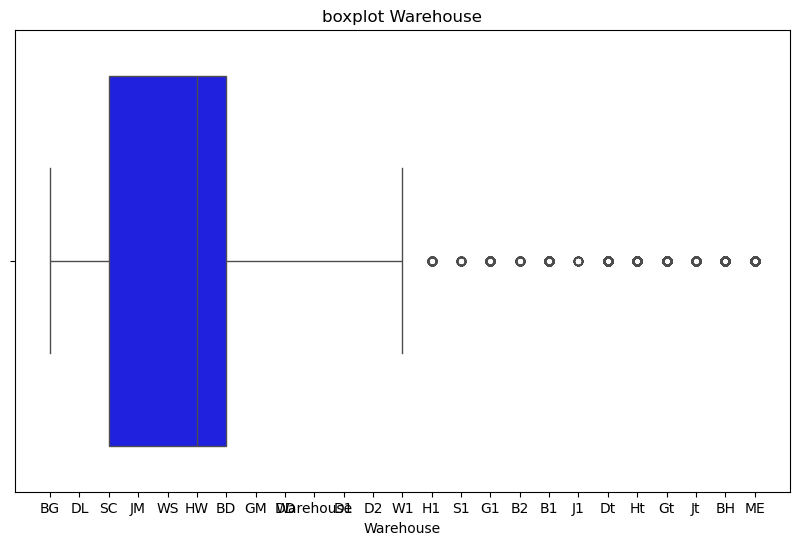

In [168]:
## detect the outlier of cholesterol
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Warehouse'],color ='blue')
plt.title('boxplot Warehouse')
plt.show()

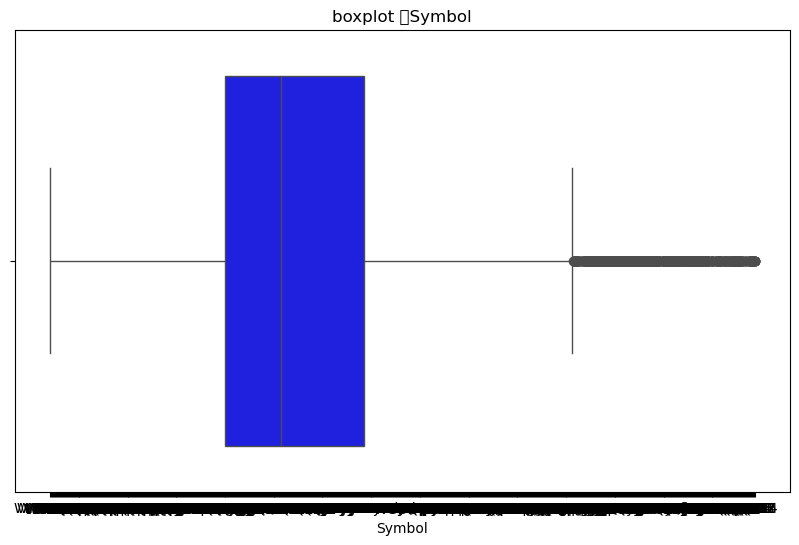

In [169]:
## detect the outlier of cholesterol
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Symbol'],color ='blue')
plt.title('boxplot 	Symbol')
plt.show()

check missing value

In [170]:
## check missing values
df.isnull().sum()

1
Trade Date            7
Symbol                7
Warehouse             7
Production Year       7
Opening Price         7
Closing Price         7
High                  7
Low                   7
Change                7
Persetntage Change    7
Volume (Ton)          7
dtype: int64

show duplication

In [171]:
df.duplicated().sum() ## show duplicate rows

np.int64(12)

**Data cleaning**
Data cleaning is the process of preparing raw data by identifying and fixing errors, missing values, duplicate records, and inconsistent formats. It improves data quality and ensures the dataset is accurate, consistent, and ready for analysis and visualization.

In [172]:
#  DATA CLEANING & STANDARDIZATION

# - Check if the misspelled column exists
# - If not, use the correctly spelled column name
df["Persetntage Change"] = df.get(     # Handle possible column name spelling variations safely:
    "Persetntage Change",
    df.get("Percentage Change")
)
# Rename the misspelled column to the correct column name
# This improves consistency for later analysis and visualization
df = df.rename(
    columns={
        "Persetntage Change": "Percentage Change"
    }
)

drop and manipulate missing value

In [173]:
## fill missing values
# 1. Drop rows where ALL columns are completely empty (NaN)
# This removes structural blank rows often imported from Excel files.
df.dropna(how='all', inplace=True)

# 2. Verify if the missing values have been resolved
print("Missing values after dropping empty rows:")
print(df.isnull().sum())

Missing values after dropping empty rows:
1
Trade Date           0
Symbol               0
Warehouse            0
Production Year      0
Opening Price        0
Closing Price        0
High                 0
Low                  0
Change               0
Percentage Change    0
Volume (Ton)         0
dtype: int64


identify and remove duplication

In [174]:
# 1. Identify and inspect the duplicated rows before removing them
# This keeps the first occurrence and shows you exactly what is being deleted.
duplicate_rows = df[df.duplicated(keep='first')]
print(f"Total duplicate rows found: {len(duplicate_rows)}")
print(duplicate_rows.head())

# 2. Remove the duplicate rows
# 'keep="first"' ensures the original record stays, and 'inplace=True' applies it directly to the dataframe.
df.drop_duplicates(keep='first', inplace=True)

# 3. Verify that duplicates have been completely removed
# This should now return 0.
print(f"Remaining duplicates: {df.duplicated().sum()}")

Total duplicate rows found: 6
1      Trade Date  Symbol  Warehouse  Production Year  Opening Price  \
20984  Trade Date  Symbol  Warehouse  Production Year  Opening Price   
32024  Trade Date  Symbol  Warehouse  Production Year  Opening Price   
43760  Trade Date  Symbol  Warehouse  Production Year  Opening Price   
54696  Trade Date  Symbol  Warehouse  Production Year  Opening Price   
66710  Trade Date  Symbol  Warehouse  Production Year  Opening Price   

1      Closing Price  High  Low  Change   Percentage Change  Volume (Ton)  
20984  Closing Price  High  Low  Change  Persetntage Change  Volume (Ton)  
32024  Closing Price  High  Low  Change  Persetntage Change  Volume (Ton)  
43760  Closing Price  High  Low  Change  Persetntage Change  Volume (Ton)  
54696  Closing Price  High  Low  Change  Persetntage Change  Volume (Ton)  
66710  Closing Price  High  Low  Change  Persetntage Change  Volume (Ton)  
Remaining duplicates: 0


In [175]:
df.duplicated().sum()

np.int64(0)

**Feature Engineering**:
Feature engineering is the process of creating new useful variables (features) from existing data to improve analysis and model performance. It helps extract meaningful information and patterns from raw data

In [176]:


# 1. Convert the 'Trade Date' column to Datetime format
# errors='coerce' will transform invalid or unrecognized date formats into NaT (Not a Time) instead of throwing an error.
df['Trade Date'] = pd.to_datetime(df['Trade Date'], errors='coerce')

# 2. Verify that the transformation was successful (Data Type check)
# This should print 'datetime64[ns]' as the data type.
print("Column Data Type:")
print(df['Trade Date'].dtypes)

# 3. Perform Feature Engineering to extract useful columns for the dashboard
# Once converted to Datetime, we can easily extract the year, month name, and day into separate columns.
df['Year'] = df['Trade Date'].dt.year          # Extracts the year component (e.g., 2012)
df['Month'] = df['Trade Date'].dt.month_name() # Extracts the full name of the month (e.g., January)
df['Day'] = df['Trade Date'].dt.day            # Extracts the day component (e.g., 3)

# 4. Display a sample of the updated dataframe
print("\nSample of the transformed data:")
print(df[['Trade Date', 'Year', 'Month', 'Day']].head())

Column Data Type:
datetime64[ns]

Sample of the transformed data:
1 Trade Date    Year    Month   Day
0 2012-01-02  2012.0  January   2.0
1 2012-01-03  2012.0  January   3.0
2 2012-01-04  2012.0  January   4.0
3 2012-01-06  2012.0  January   6.0
4 2012-01-12  2012.0  January  12.0


In [177]:
df.info() ## understand the structure and data types of the dataset after transformation

<class 'pandas.core.frame.DataFrame'>
Index: 91424 entries, 0 to 91436
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Trade Date         91423 non-null  datetime64[ns]
 1   Symbol             91424 non-null  object        
 2   Warehouse          91424 non-null  object        
 3   Production Year    91424 non-null  object        
 4   Opening Price      91424 non-null  object        
 5   Closing Price      91424 non-null  object        
 6   High               91424 non-null  object        
 7   Low                91424 non-null  object        
 8   Change             91424 non-null  object        
 9   Percentage Change  91424 non-null  object        
 10  Volume (Ton)       91424 non-null  object        
 11  Year               91423 non-null  float64       
 12  Month              91423 non-null  object        
 13  Day                91423 non-null  float64       
dtypes: datetime

remove unnecessarythings and convort suitable format

In [178]:

# Convert Production Year column to a clean integer format


df["Production Year"] = (
    df["Production Year"]
    .astype(str)          # Convert values to string for text cleaning
    .str.strip()          # Remove leading and trailing spaces
)

df["Production Year"] = pd.to_numeric(
    df["Production Year"],
    errors="coerce"       # Convert invalid values to missing values (NaN)
).astype("Int64")         # Store as nullable integer type

# Clean and convert numeric columns
numeric_cols = [
    "Opening Price",
    "Closing Price",
    "High",
    "Low",
    "Change",
    "Percentage Change",
    "Volume (Ton)"
]
for col in numeric_cols:

    # Convert column values to string for consistent cleaning
    df[col] = df[col].astype(str)

    # Remove unnecessary spaces from values
    df[col] = df[col].str.strip()

    # Remove commas from numbers (e.g., 1,000 → 1000)
    df[col] = df[col].str.replace(",", "", regex=False)

    # Remove percentage symbols (e.g., 5% → 5)
    df[col] = df[col].str.replace("%", "", regex=False)

    # Remove hidden non-breaking spaces
    df[col] = df[col].str.replace("\xa0", "", regex=False)

    # Remove all remaining spaces inside values
    df[col] = df[col].str.replace(r"\s+", "", regex=True)

    # Convert cleaned values into numeric format
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"   # Replace invalid values with NaN
    )

# Create new date-based features

# Extract year from Trade Date
df["Year"] = df["Trade Date"].dt.year.astype("Int64")

# Extract month name from Trade Date
df["Month"] = df["Trade Date"].dt.month_name()

# Extract day from Trade Date
df["Day"] = df["Trade Date"].dt.day.astype("Int64")

# Check final dataset information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 91424 entries, 0 to 91436
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Trade Date         91423 non-null  datetime64[ns]
 1   Symbol             91424 non-null  object        
 2   Warehouse          91424 non-null  object        
 3   Production Year    91423 non-null  Int64         
 4   Opening Price      91423 non-null  float64       
 5   Closing Price      91423 non-null  float64       
 6   High               91423 non-null  float64       
 7   Low                91423 non-null  float64       
 8   Change             91423 non-null  float64       
 9   Percentage Change  91423 non-null  float64       
 10  Volume (Ton)       91423 non-null  float64       
 11  Year               91423 non-null  Int64         
 12  Month              91423 non-null  object        
 13  Day                91423 non-null  Int64         
dtypes: Int64(3)

In [179]:
df[df.isnull().any(axis=1)]

1,Trade Date,Symbol,Warehouse,Production Year,Opening Price,Closing Price,High,Low,Change,Percentage Change,Volume (Ton),Year,Month,Day
10362,NaT,Symbol,Warehouse,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,<NA>


In [180]:
df = df.dropna().reset_index(drop=True)

In [181]:
df[df.isnull().any(axis=1)]

1,Trade Date,Symbol,Warehouse,Production Year,Opening Price,Closing Price,High,Low,Change,Percentage Change,Volume (Ton),Year,Month,Day


In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91423 entries, 0 to 91422
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Trade Date         91423 non-null  datetime64[ns]
 1   Symbol             91423 non-null  object        
 2   Warehouse          91423 non-null  object        
 3   Production Year    91423 non-null  Int64         
 4   Opening Price      91423 non-null  float64       
 5   Closing Price      91423 non-null  float64       
 6   High               91423 non-null  float64       
 7   Low                91423 non-null  float64       
 8   Change             91423 non-null  float64       
 9   Percentage Change  91423 non-null  float64       
 10  Volume (Ton)       91423 non-null  float64       
 11  Year               91423 non-null  Int64         
 12  Month              91423 non-null  object        
 13  Day                91423 non-null  Int64         
dtypes: Int

**KPI** stands for Key Performance Indicator.

A KPI is a number or metric that shows how well something is performing. It gives users a quick summary of the most important information before they look at charts

In [183]:

# KPI Calculations

# Total Trading Volume
total_volume = df["Volume (Ton)"].sum()

# Average Opening Price
avg_opening = df["Opening Price"].mean()

# Average Closing Price
avg_closing = df["Closing Price"].mean()

# Highest Price
highest_price = df["High"].max()

# Lowest Price
lowest_price = df["Low"].min()

# Average Percentage Change
avg_change = df["Percentage Change"].mean()

# Number of Warehouses
total_warehouses = df["Warehouse"].nunique()

# Number of Symbols
total_symbols = df["Symbol"].nunique()

# Number of Trading Days
trading_days = df["Trade Date"].nunique()

In [184]:
# Filter out records where Closing Price is 0 or less
df_cleaned = df[df["Closing Price"] > 0].copy()

# Print status check
print(f"Total records before cleaning: {len(df):,}")
print(f"Total records after cleaning: {len(df_cleaned):,}")
print(f"Total records removed: {len(df) - len(df_cleaned):,}")

# Export cleaned data
df_cleaned.to_csv("cleaned_coffee_data.csv", index=False)

Total records before cleaning: 91,423
Total records after cleaning: 80,933
Total records removed: 10,490


In [185]:


# Load the cleaned dataset into a pandas DataFrame
df = pd.read_csv("cleaned_coffee_data.csv")

# Convert the 'Trade Date' column to datetime objects
# 'errors="coerce"' replaces any unparseable or invalid dates with NaT (Not a Time/null)
df["Trade Date"] = pd.to_datetime(df["Trade Date"], errors="coerce")

**Data Visualization**

Data visualization is the process of presenting data in graphical and visual formats such as charts, graphs, maps, and dashboards. It helps users understand complex data quickly, identify trends and patterns, detect outliers, and make informed decisions. Effective data visualization transforms raw data into meaningful insights, making information easier to interpret and communicate. Common visualization types include bar charts, line charts, pie charts, scatter plots, and dashboards.


## linechart

A line chart is a graph used to show trends or changes over time.
.Data points are connected by lines
.Useful for identifying trends, patterns, and growth/decline

show Coffee Closing Price Trend (Monthly Average)

In [186]:

# 4. Sort chronologically by date
df_cleaned = df_cleaned.sort_values("Trade Date")

# 5. Aggregate data by Month using average closing price
df_monthly = (
    df_cleaned.set_index("Trade Date")
    .resample("ME")["Closing Price"]
    .mean()
    .reset_index()
)

# 6. Create the Plotly line chart
fig_closing = px.line(
    df_monthly,
    x="Trade Date",
    y="Closing Price",
    title="Closing Price Trend Over Time",
    labels={
        "Trade Date": "Trade Date",
        "Closing Price": "Closing Price (ETB)",
    },
)

# 7. Improve graph layout and styling
fig_closing.update_layout(
    template="plotly_white",
    title={
        "text": "Coffee Closing Price Trend (Monthly Average)",
        "x": 0.5,
        "xanchor": "center",
    },
    xaxis_title="Trade Date",
    yaxis_title="Closing Price (ETB)",
    hovermode="x unified",
    height=500,
)

# 8. Set coffee-brown line styling
fig_closing.update_traces(line=dict(color="#A52A2A", width=3), mode="lines")

# 9. Render the plot in Jupyter Notebook
fig_closing.show()

high vs low trade price

In [187]:


# 1. Convert 'Trade Date' to proper pandas datetime format (if not already done)
df['Trade Date'] = pd.to_datetime(df['Trade Date'])

# 2. Sort the data chronologically by date
df = df.sort_values("Trade Date")

# 3. Aggregate data by Month to prevent overplotting (91k rows -> clean trend)
# We take the max of 'High' and the min of 'Low' for each month to see the true market range
df_monthly_range = df.set_index('Trade Date').resample('M').agg({
    'High': 'max',
    'Low': 'min'
}).reset_index()

# 4. Melt the data into long format so Plotly Express can plot multiple lines automatically
df_melted = df_monthly_range.melt(
    id_vars=["Trade Date"], 
    value_vars=["High", "Low"],
    var_name="Price Type", 
    value_name="Price (ETB)"
)

# 5. Create the Multi-Line Chart
fig_high_low = px.line(
    df_melted,
    x="Trade Date",
    y="Price (ETB)",
    color="Price Type", # Creates two distinct lines automatically based on High vs Low
    title="Monthly High vs Low Price Trend",
    color_discrete_map={
        "High": "#228B22",  # Forest Green for High prices
        "Low": "#DC143C"    # Crimson Red for Low prices
    },
    labels={"Trade Date": "Trade Date", "Price (ETB)": "Price (ETB)"}
)

# 6. Improve the dashboard layout appearance
fig_high_low.update_layout(
    template="plotly_white",
    title={
        "text": "📈 Coffee Price Range Trend (Monthly High vs Low)",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Trade Date",
    yaxis_title="Price (ETB)",
    hovermode="x unified", # Shows both High and Low values together when hovering over a date
    height=500
)

# 7. Make the lines smoother and distinct
fig_high_low.update_traces(
    line=dict(width=2.5),
    mode="lines"
)

# 8. Display the chart in your Jupyter Notebook
fig_high_low.show()

## Barchart

**bar chart** is a simple data visualization used to compare values across categories.

.Each category is represented by a rectangular bar
.The height (or length) of the bar shows the value or frequency
.Bars can be vertical or horizontal
.Useful for comparing different groups clearly and quickly

visualize trade volume by warehouse

In [188]:

# 1. DATA AGGREGATION & SORTING
# Group records by 'Warehouse' and compute the total trading volume for each location
warehouse_volume = (
    df.groupby("Warehouse")["Volume (Ton)"].sum().reset_index()
)

# Sort the warehouses in descending order based on total volume (highest to lowest)
warehouse_volume = warehouse_volume.sort_values(
    by="Volume (Ton)", ascending=False
)

# 2. CREATE VERTICAL BAR CHART

fig_warehouse = px.bar(
    warehouse_volume,
    x="Warehouse",  # Warehouse locations on X-axis
    y="Volume (Ton)",  # Total volume metric on Y-axis
    title="Trading Volume by Warehouse",  # Fallback chart title
    labels={
        "Warehouse": "Warehouse",
        "Volume (Ton)": "Trading Volume (Ton)",
    },  # Custom axis labels
    text_auto=".2s",  # Format large numerical values into concise SI suffixes (e.g., 1.2M, 450k)
)

# 3. CUSTOMIZE DASHBOARD LAYOUT & APPEARANCE
fig_warehouse.update_layout(
    template="plotly_white",  # Apply a clean, minimalist white theme
    title={
        "text": "Trading Volume by Warehouse",  # Main title text
        "x": 0.5,  # Horizontally center the title (0 = left, 1 = right)
        "xanchor": "center",  # Set title anchor point to the center
    },
    xaxis_title="Warehouse",  # X-axis label
    yaxis_title="Trading Volume (Ton)",  # Y-axis label
    height=500,  # Set vertical chart height in pixels
)

# 4. STYLE BAR CHART TRACES
fig_warehouse.update_traces(
    marker_color="#8B4513",  # Apply a Saddle Brown color matching the coffee dashboard theme
    textposition="outside",  # Position formatted text values neatly above each bar
)

# 5. DISPLAY THE PLOT
# Render the interactive bar chart figure inside Jupyter Notebook
fig_warehouse.show()

visualze  monthly coffee tranding volume trend

In [189]:

# 1. DATE PREPROCESSING & SORTING
# Convert 'Trade Date' column into pandas datetime objects for time-based operations
df["Trade Date"] = pd.to_datetime(df["Trade Date"])

# Sort the entire dataset chronologically in ascending order
df = df.sort_values("Trade Date")

# 2. DATA AGGREGATION & RESAMPLING
# Group data by calendar month end ('M') and sum total trading volumes per month
# This resamples large datasets into a structured monthly time-series DataFrame
df_monthly_volume = (
    df.set_index("Trade Date")
    .resample("M")["Volume (Ton)"]
    .sum()
    .reset_index()
)

# 3. CREATE VERTICAL BAR CHART
fig_monthly_volume = px.bar(
    df_monthly_volume,
    x="Trade Date",  # Monthly date timeline on X-axis
    y="Volume (Ton)",  # Aggregated trading volume on Y-axis
    title="Monthly Trading Volume Trend",  # Fallback chart title
    labels={
        "Trade Date": "Timeline",
        "Volume (Ton)": "Trading Volume (Tons)",
    },  # Custom axis labels
    text_auto=".2s",  # Format large numerical values into concise SI suffixes (e.g., 1.2M, 450k)
)
# 4. CUSTOMIZE DASHBOARD LAYOUT & APPEARANCE
fig_monthly_volume.update_layout(
    template="plotly_white",  # Apply a clean, minimalist white theme
    title={
        "text": "Monthly Coffee Trading Volume Trend",  # Centered title text
        "x": 0.5,  # Horizontally center the title (0 = left, 1 = right)
        "xanchor": "center",  # Anchor point for precise title alignment
    },
    xaxis_title="Timeline (Months)",  # X-axis label
    yaxis_title="Trading Volume (Tons)",  # Y-axis label
    height=500,  # Set vertical chart height in pixels
)

# 5. STYLE BAR CHART TRACES
fig_monthly_volume.update_traces(
    marker_color="#8B4513",  # Apply a Saddle Brown color matching the coffee dashboard theme
    textposition="outside",  # Position formatted text values neatly above each bar
)
# 6. DISPLAY THE PLOT
# Render the interactive bar chart figure inside Jupyter Notebook
fig_monthly_volume.show()

In [190]:
df.columns

Index(['Trade Date', 'Symbol', 'Warehouse', 'Production Year', 'Opening Price',
       'Closing Price', 'High', 'Low', 'Change', 'Percentage Change',
       'Volume (Ton)', 'Year', 'Month', 'Day'],
      dtype='object')

In [191]:

# 1. DATE PREPROCESSING & FEATURE EXTRACTION
# Convert 'Trade Date' column into pandas datetime objects for time-based operations
df["Trade Date"] = pd.to_datetime(df["Trade Date"])
# Extract the calendar year from the datetime objects into a dedicated column
df["Year"] = df["Trade Date"].dt.year
# 2. DATA AGGREGATION
# Group records by year and compute the mean closing price for each year
df_yearly_price = df.groupby("Year")["Closing Price"].mean().reset_index()

# Sort the aggregated dataset chronologically in ascending order
df_yearly_price = df_yearly_price.sort_values("Year", ascending=True)
# 3. CREATE VERTICAL BAR CHART

fig_yearly_price = px.bar(
    df_yearly_price,
    x="Year",  # Categorical feature on X-axis
    y="Closing Price",  # Metric feature on Y-axis
    title="Average Closing Price by Production Year",  # Fallback chart title
    labels={
        "Year": "Production Year",
        "Closing Price": "Average Closing Price (ETB)",
    },  # Custom axis labels
    text_auto=".2f",  # Automatically display values formatted to 2 decimal places on bars
)

# 4. CUSTOMIZE DASHBOARD LAYOUT & AXES
fig_yearly_price.update_layout(
    template="plotly_white",  # Apply a clean, minimalist white theme
    title={
        "text": "Average Closing Price by Production Year",  # Centered title text
        "x": 0.5,  # Horizontally center the title (0 = left, 1 = right)
        "xanchor": "center",  # Anchor point for precise title alignment
    },
    xaxis_title="Production Year",  # X-axis title
    yaxis_title="Average Closing Price (ETB)",  # Y-axis title
    xaxis=dict(
        type="category"
    ),  # Treat years as discrete categorical labels rather than continuous numeric values
    height=500,  # Set vertical chart height in pixels
)

# 5. STYLE BAR CHART TRACES
fig_yearly_price.update_traces(
    marker_color="#4169E1",  # Apply a consistent Royal Blue color to bars
    textposition="outside",  # Position the numerical value labels neatly above each bar
)

# 6. DISPLAY THE PLOT
# Render the interactive bar chart figure inside Jupyter Notebook
fig_yearly_price.show()

### cross tabulation

Cross-tabulation (Crosstab) is a table used to summarize and compare two categorical variables by showing how they relate to each other.

In [192]:
# CROSS-TABULATION ANALYSIS
# 1. Warehouse × Coffee Symbol
print("\n1️⃣ CROSS-TABULATION ANALYSIS: Warehouse vs Coffee Symbol")

cross_tab_1 = pd.pivot_table(
    df,
    index="Warehouse",
    columns="Symbol",
    values="Volume (Ton)",
    aggfunc="sum",
    fill_value=0
)

# Display only the first 5 rows
display(cross_tab_1.head(5))


1️⃣ CROSS-TABULATION ANALYSIS: Warehouse vs Coffee Symbol


Symbol,LUAM4,LUBL1,LUBL2,LUBL5A,LUBL5B,LUBL5C,LUBM1,LUBM2,LUBM3,LUBM4,...,WYCB4,WYCB5,WYCB6,WYCB7,WYCB8,WYCB9,WYCBUGnp,WYCBUGp,WYKQ1,WYKQ2
Warehouse,,,,,,,,,,,,,,,,,,,,,
B1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00
B2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00
BD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00
BG,0.0,0.0,0.0,0.0,0.0,0.0,5.1,171.45,122.79,28.55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,243.95,3873.13
BH,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00


In [193]:
# 2. Year × Warehouse


print("\n2️⃣ Year vs Warehouse")

cross_tab_2 = pd.pivot_table(
    df,
    index="Year",
    columns="Warehouse",
    values="Volume (Ton)",
    aggfunc="sum",
    fill_value=0
)

display(cross_tab_2.head(5))


2️⃣ Year vs Warehouse


Warehouse,B1,B2,BD,BG,BH,D1,D2,DD,DL,Dt,...,HW,Ht,J1,JM,Jt,ME,S1,SC,W1,WS
Year,,,,,,,,,,,,,,,,,,,,,
2012,0.00,0.00,104.96,193.13,0.0,0.00,0.00,47.53,80.99,0.00,...,658.20,0.00,0.00,335.96,0.00,0.0,0.00,163.40,0.00,41.94
2013,0.00,0.00,19478.64,30024.03,0.0,0.00,0.00,9053.81,21185.34,0.00,...,56299.30,0.00,0.00,17728.46,0.00,0.0,0.00,25104.23,0.00,6826.87
2014,0.00,0.00,19546.04,38035.71,0.0,0.00,0.00,12387.41,21942.39,0.00,...,51935.43,0.00,0.00,44659.04,0.00,0.0,0.00,23640.41,0.00,9353.69
2015,1206.97,254.11,17477.07,22849.88,0.0,110.01,947.97,16401.65,19615.81,0.00,...,62964.73,0.00,82.30,20126.58,0.00,0.0,15.63,27624.20,101.83,3979.97
2016,1938.46,488.15,25644.19,38703.85,0.0,219.53,731.45,12839.93,16746.90,1994.62,...,50476.85,3717.98,56.13,22906.76,3241.63,0.0,242.66,27376.68,89.46,7478.05


In [194]:
# 3. Year × Coffee Symbol

print("\n3️⃣ Year vs Coffee Symbol")

cross_tab_3 = pd.pivot_table(
    df,
    index="Year",
    columns="Symbol",
    values="Volume (Ton)",
    aggfunc="sum",
    fill_value=0
)

display(cross_tab_3.head(10))


3️⃣ Year vs Coffee Symbol


Symbol,LUAM4,LUBL1,LUBL2,LUBL5A,LUBL5B,LUBL5C,LUBM1,LUBM2,LUBM3,LUBM4,...,WYCB4,WYCB5,WYCB6,WYCB7,WYCB8,WYCB9,WYCBUGnp,WYCBUGp,WYKQ1,WYKQ2
Year,,,,,,,,,,,,,,,,,,,,,
2012,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,25.98
2013,0.00,0.00,0.0,74.15,68.49,0.00,0.00,0.00,0.00,0.00,...,501.16,77.33,77.50,80.95,35.36,27.92,217.24,36.79,9.16,792.76
2014,0.00,0.00,0.0,28.05,377.00,17.85,0.00,0.00,0.00,0.00,...,265.01,147.16,97.67,57.73,25.16,3.60,145.32,61.42,19.48,240.05
2015,0.00,0.00,0.0,0.00,191.03,30.18,0.00,0.00,0.00,0.00,...,290.77,232.72,189.00,57.07,34.00,9.98,123.93,107.17,23.39,480.64
2016,0.00,0.00,0.0,0.00,193.80,0.00,0.00,0.00,0.00,0.00,...,113.89,43.49,0.00,0.00,0.00,0.00,256.87,24.27,55.15,621.78
2017,0.00,0.00,5.1,0.00,165.75,0.00,0.00,0.00,0.00,0.00,...,149.27,130.47,0.00,0.00,0.00,0.00,176.34,149.89,39.58,952.65
2018,2.55,6.36,0.0,12.38,341.30,0.00,5.10,22.95,17.85,0.00,...,60.82,54.71,0.00,0.00,0.00,0.00,135.72,19.81,97.19,590.68
2019,3.49,0.00,0.0,0.00,0.00,0.00,46.12,170.14,108.53,45.47,...,221.17,10.82,0.00,0.00,0.00,0.00,33.50,13.87,0.00,168.59
